In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Climate Region Discovery by Feature Engineering + PCA + UMAP + HDBSCAN

import os
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, entropy, spearmanr
from scipy.signal import periodogram
from scipy.fft import rfft, rfftfreq
from statsmodels.tsa.seasonal import STL
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
try:
    import pywt
except ImportError:
    !pip install PyWavelets -q
    import pywt
try:
    import umap
except ImportError:
    !pip install umap-learn -q
    import umap
try:
    import hdbscan
except ImportError:
    !pip install hdbscan -q
    import hdbscan

In [ ]:
# Locate cleaned dataset from Google Drive

BASE_DIR = "/content/drive/MyDrive/Weather Trend Forecasting"
candidate_files = []
for root, dirs, files in os.walk(BASE_DIR):
    for f in files:
        if f.endswith(".csv"):
            name = f.lower()
            path = os.path.join(root, f)
            score = 0
            if "globalweatherrepository" in name:
                score += 5
            if "missing" in name:
                score += 2
            if "outlier" in name:
                score += 5
            if "cleaned" in name:
                score += 5
            if "city" in name or "summary" in name or "metrics" in name:
                score -= 5
            if "prediction" in root.lower():
                score -= 5
            candidate_files.append({
                "path": path,
                "file": f,
                "score": score
            })

candidate_df = pd.DataFrame(candidate_files).sort_values("score", ascending=False)
display(candidate_df.head(20))
DATA_FILE = candidate_df.iloc[0]["path"]
print("Selected DATA_FILE:")
print(DATA_FILE)
df = pd.read_csv(DATA_FILE)
print("Raw data shape:", df.shape)
print(df.columns.tolist())
display(df.head())

,path,file,score
522,/content/drive/MyDrive/Weather Trend Forecasti...,GlobalWeatherRepository_missing_outlier_cleane...,17
4,/content/drive/MyDrive/Weather Trend Forecasti...,GlobalWeatherRepository_missing_cleaned.csv,12
768,/content/drive/MyDrive/Weather Trend Forecasti...,Vilnius_outlier_cleaned.csv,10
771,/content/drive/MyDrive/Weather Trend Forecasti...,Wellington_outlier_cleaned.csv,10
772,/content/drive/MyDrive/Weather Trend Forecasti...,Warsaw_outlier_cleaned.csv,10
773,/content/drive/MyDrive/Weather Trend Forecasti...,Windhoek_outlier_cleaned.csv,10
774,/content/drive/MyDrive/Weather Trend Forecasti...,Washington_Park_outlier_cleaned.csv,10
775,/content/drive/MyDrive/Weather Trend Forecasti...,Yaounde_outlier_cleaned.csv,10
776,/content/drive/MyDrive/Weather Trend Forecasti...,Yaren_outlier_cleaned.csv,10
769,/content/drive/MyDrive/Weather Trend Forecasti...,Yamoussoukro_outlier_cleaned.csv,10


Selected DATA_FILE:
/content/drive/MyDrive/Weather Trend Forecasting/processed_outputs/outlier_processed_outputs/GlobalWeatherRepository_missing_outlier_cleaned.csv
Raw data shape: (141508, 41)
['last_updated', 'country', 'location_name', 'latitude', 'longitude', 'timezone', 'last_updated_epoch', 'temperature_celsius', 'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph', 'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km', 'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination']


,last_updated,country,location_name,latitude,longitude,timezone,last_updated_epoch,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,2024-05-31 16:15:00,Belgium,'S Gravenjansdijk,51.25,3.63,Europe/Brussels,1717164900,16.0,60.8,Moderate rain,...,2.2,3.4,1,1,05:36 AM,09:52 PM,02:59 AM,02:09 PM,Waning Crescent,47
1,2024-06-01 16:30:00,Belgium,'S Gravenjansdijk,51.25,3.63,Europe/Brussels,1717252200,16.0,60.8,Overcast,...,6.5,19.6,1,1,05:35 AM,09:53 PM,03:12 AM,03:34 PM,Waning Crescent,35
2,2024-06-04 16:15:00,Belgium,'S Gravenjansdijk,51.25,3.63,Europe/Brussels,1717510500,18.0,64.4,Partly cloudy,...,5.7,6.0,1,1,05:33 AM,09:56 PM,03:56 AM,07:57 PM,Waning Crescent,8
3,2024-06-05 16:15:00,Belgium,'S Gravenjansdijk,51.25,3.63,Europe/Brussels,1717596900,15.0,59.0,Partly cloudy,...,1.2,2.4,1,1,05:33 AM,09:56 PM,04:17 AM,09:25 PM,Waning Crescent,3
4,2024-06-11 16:15:00,Belgium,'S Gravenjansdijk,51.25,3.63,Europe/Brussels,1718115300,15.2,59.4,Partly cloudy,...,0.5,0.9,1,1,05:30 AM,10:01 PM,10:16 AM,01:31 AM,Waxing Crescent,21


In [ ]:
# Column detection

def find_col(possible_names, columns):
    col_map = {c.lower(): c for c in columns}
    for name in possible_names:
        if name.lower() in col_map:
            return col_map[name.lower()]
    for c in columns:
        c_low = c.lower()
        for name in possible_names:
            if name.lower() in c_low:
                return c
    return None


country_col = find_col(["country", "country_name"], df.columns)
city_col = find_col(["location_name", "city", "location"], df.columns)
time_col = find_col(["last_updated", "datetime", "date", "time"], df.columns)
lat_col = find_col(["latitude", "lat"], df.columns)
lon_col = find_col(["longitude", "lon", "lng"], df.columns)

print("country_col:", country_col)
print("city_col:", city_col)
print("time_col:", time_col)
print("lat_col:", lat_col)
print("lon_col:", lon_col)

if country_col is None or city_col is None:
    raise ValueError("Cannot find country or city column.")

if time_col is None:
    raise ValueError("Cannot find time column.")

country_col: country
city_col: location_name
time_col: last_updated
lat_col: latitude
lon_col: longitude


In [ ]:
# Select weather-varying numeric features
# Exclude duplicated units, location/static/time/meta columns

exclude_keywords = [
    "latitude", "longitude", "lat", "lon", "lng",
    "epoch", "last_updated", "time", "date",
    "timezone", "tz_id",
    "localtime",
    "country", "location", "city", "name",
    "region",
    "moon", "sunrise", "sunset", "moonrise", "moonset",
    "is_day",
    "condition", "text", "icon",
    "wind_mph", "wind_miles",
    "temp_f", "temperature_fahrenheit",
    "feels_like_fahrenheit", "feelslike_f",
    "pressure_in",
    "precip_in",
    "visibility_miles", "vis_miles",
    "gust_mph",
    "air_quality_Carbon_Monoxide", "air_quality_Nitrogen_dioxide", "air_quality_Sulphur_dioxide",
    "air_quality_Ozone", "air_quality_PM2.5", "air_quality_PM2.5", "air",
    "air_quality_PM10", "air_quality_us-epa-index", "air_quality_gb-defra-index"
]

numeric_cols = []
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        c_low = col.lower()
        if not any(k in c_low for k in exclude_keywords):
            numeric_cols.append(col)
print("Initial selected numeric weather features:", len(numeric_cols))
print(numeric_cols)

Initial selected numeric weather features: 11
['temperature_celsius', 'wind_kph', 'wind_degree', 'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'feels_like_celsius', 'visibility_km', 'uv_index', 'gust_kph']


In [ ]:
# Optional: manually remove columns that are duplicated or not weather-varying
manual_remove = [
    # Add names here if needed after inspecting numeric_cols
    # "some_column_name"
]

weather_features = [
    c for c in numeric_cols
    if c not in manual_remove
]

print("Final weather features:", len(weather_features))
print(weather_features)

Final weather features: 11
['temperature_celsius', 'wind_kph', 'wind_degree', 'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'feels_like_celsius', 'visibility_km', 'uv_index', 'gust_kph']


In [ ]:
# Clean and sort dataframe
df_work = df.copy()
df_work[time_col] = pd.to_datetime(
    df_work[time_col],
    errors="coerce")
for col in weather_features:
    df_work[col] = pd.to_numeric(df_work[col], errors="coerce")
df_work = df_work.dropna(
    subset=[country_col, city_col, time_col])
df_work = df_work.sort_values(
    [country_col, city_col, time_col]
).reset_index(drop=True)
print("df_work:", df_work.shape)

df_work: (141508, 41)


In [ ]:
# Select cities with sequence length > 400

city_length_df = (
    df_work
    .groupby([country_col, city_col], as_index=False)
    .agg(
        sequence_length=(time_col, "count")
    )
)

selected_city_df = city_length_df[
    city_length_df["sequence_length"] > 400].copy()

print("Total country-city groups:", len(city_length_df))
print("Selected cities length > 400:", len(selected_city_df))
display(selected_city_df.sort_values("sequence_length", ascending=False).head())

Total country-city groups: 270
Selected cities length > 400: 194


,country,location_name,sequence_length
0,Afghanistan,Kabul,728
36,Burundi,Bujumbura,728
71,Eritrea,Asmara,728
70,Equatorial Guinea,Malabo,728
83,Ghana,Accra,728


In [ ]:
# Feature extraction helpers

def safe_entropy(x, bins=20):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 5:
        return np.nan
    hist, _ = np.histogram(x, bins=bins, density=False)
    prob = hist / np.sum(hist)
    prob = prob[prob > 0]
    return entropy(prob)


def spectral_entropy(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 8:
        return np.nan
    x = x - np.mean(x)
    freqs, power = periodogram(x)
    power = power[1:]
    if len(power) == 0 or np.sum(power) <= 0:
        return 0.0
    p = power / np.sum(power)
    return entropy(p) / np.log(len(p))


def wavelet_energy_entropy(x, wavelet="db4", level=None):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 16:
        return np.nan, np.nan
    max_level = pywt.dwt_max_level(
        data_len=len(x),
        filter_len=pywt.Wavelet(wavelet).dec_len
    )
    if max_level < 1:
        return np.nan, np.nan
    if level is None:
        level = min(4, max_level)
    coeffs = pywt.wavedec(
        x,
        wavelet=wavelet,
        level=level
    )

    energies = np.array([
        np.sum(c ** 2)
        for c in coeffs
    ], dtype=float)
    total_energy = np.sum(energies)
    if total_energy <= 0:
        return 0.0, 0.0
    p = energies / total_energy
    w_entropy = entropy(p) / np.log(len(p))
    return total_energy, w_entropy


def stl_features(x, period=30):
    x = np.asarray(x, dtype=float)

    if np.sum(np.isfinite(x)) < max(2 * period, 60):
        return {
            "stl_trend_strength": np.nan,
            "stl_trend_std": np.nan,
            "stl_seasonal_strength": np.nan,
            "stl_seasonal_std": np.nan,
            "stl_trend_main_freq": np.nan,
            "stl_trend_main_energy": np.nan,
            "stl_seasonal_main_freq": np.nan,
            "stl_seasonal_main_energy": np.nan,
        }

    x = pd.Series(x).interpolate(limit_direction="both").values
    try:
        res = STL(x,
            period=period,
            robust=True).fit()
        trend = res.trend
        seasonal = res.seasonal
        resid = res.resid
        var_total = np.var(x)
        var_resid = np.var(resid)
        var_deseason = np.var(x - seasonal)
        var_detrend = np.var(x - trend)
        if var_total <= 1e-12:
            trend_strength = 0.0
            seasonal_strength = 0.0
        else:
            trend_strength = max(0.0, 1.0 - var_resid / max(var_detrend, 1e-12))
            seasonal_strength = max(0.0, 1.0 - var_resid / max(var_deseason, 1e-12))

        def fft_main_freq_energy(signal):
            signal = np.asarray(signal, dtype=float)
            signal = signal - np.mean(signal)
            yf = np.abs(rfft(signal)) ** 2
            xf = rfftfreq(len(signal), d=1.0)
            if len(yf) <= 1 or np.sum(yf[1:]) <= 0:
                return 0.0, 0.0
            yf_nozero = yf[1:]
            xf_nozero = xf[1:]
            idx = np.argmax(yf_nozero)
            main_freq = xf_nozero[idx]
            main_energy_ratio = yf_nozero[idx] / np.sum(yf_nozero)
            return main_freq, main_energy_ratio

        trend_freq, trend_energy = fft_main_freq_energy(trend)
        seasonal_freq, seasonal_energy = fft_main_freq_energy(seasonal)

        return {
            "stl_trend_strength": trend_strength,
            "stl_trend_std": np.std(trend),
            "stl_seasonal_strength": seasonal_strength,
            "stl_seasonal_std": np.std(seasonal),
            "stl_trend_main_freq": trend_freq,
            "stl_trend_main_energy": trend_energy,
            "stl_seasonal_main_freq": seasonal_freq,
            "stl_seasonal_main_energy": seasonal_energy,
        }

    except Exception:
        return {
            "stl_trend_strength": np.nan,
            "stl_trend_std": np.nan,
            "stl_seasonal_strength": np.nan,
            "stl_seasonal_std": np.nan,
            "stl_trend_main_freq": np.nan,
            "stl_trend_main_energy": np.nan,
            "stl_seasonal_main_freq": np.nan,
            "stl_seasonal_main_energy": np.nan,
        }


def extract_one_feature_stats(x):
    x = pd.Series(x).astype(float)
    x = x.interpolate(limit_direction="both")
    arr = x.values
    arr = arr[np.isfinite(arr)]

    if len(arr) < 10:
        base = {
            "mean": np.nan,
            "std": np.nan,
            "max": np.nan,
            "min": np.nan,
            "iqr": np.nan,
            "q25": np.nan,
            "q50": np.nan,
            "q75": np.nan,
            "skew": np.nan,
            "kurtosis": np.nan,
            "entropy": np.nan,
            "spectral_entropy": np.nan,
            "wavelet_energy": np.nan,
            "wavelet_entropy": np.nan,
        }
    else:
        q25, q50, q75 = np.nanpercentile(arr, [25, 50, 75])
        wave_e, wave_ent = wavelet_energy_entropy(arr)

        base = {
            "mean": np.nanmean(arr),
            "std": np.nanstd(arr),
            "max": np.nanmax(arr),
            "min": np.nanmin(arr),
            "iqr": q75 - q25,
            "q25": q25,
            "q50": q50,
            "q75": q75,
            "skew": skew(arr, nan_policy="omit"),
            "kurtosis": kurtosis(arr, nan_policy="omit"),
            "entropy": safe_entropy(arr),
            "spectral_entropy": spectral_entropy(arr),
            "wavelet_energy": wave_e,
            "wavelet_entropy": wave_ent,
        }

    base.update(stl_features(arr, period=30))
    return base

In [ ]:
# Extract city-level climate feature vector
# For each feature: 14 statistical + 8 STL/FFT = 22
# Plus 6 Spearman correlations among temp/humidity/wind/precip

temp_feature = find_col(
    ["temperature_celsius", "temp_c", "temperature"],
    weather_features
)

humidity_feature = find_col(
    ["humidity"],
    weather_features
)

wind_feature = find_col(
    ["wind_kph", "wind"],
    weather_features
)

precip_feature = find_col(
    ["precip_mm", "precipitation", "rain"],
    weather_features
)

main_corr_features = {
    "temperature": temp_feature,
    "humidity": humidity_feature,
    "wind": wind_feature,
    "precipitation": precip_feature
}

print("Main correlation features:")
print(main_corr_features)

Main correlation features:
{'temperature': 'temperature_celsius', 'humidity': 'humidity', 'wind': 'wind_kph', 'precipitation': 'precip_mm'}


In [ ]:
feature_records = []

selected_pairs = set(
    zip(
        selected_city_df[country_col],
        selected_city_df[city_col]
    )
)

for i, (country, city) in enumerate(selected_pairs):
    print(f"[{i+1}/{len(selected_pairs)}] Extracting features: {city}, {country}")
    city_data = df_work[
        (df_work[country_col] == country) &
        (df_work[city_col] == city)
    ].sort_values(time_col)

    record = {
        "country": country,
        "location_name": city,
        "sequence_length": len(city_data)
    }

    if lat_col is not None:
        record["latitude"] = pd.to_numeric(city_data[lat_col], errors="coerce").mean()

    if lon_col is not None:
        record["longitude"] = pd.to_numeric(city_data[lon_col], errors="coerce").mean()

    for feat in weather_features:
        stats = extract_one_feature_stats(city_data[feat].values)

        for stat_name, stat_value in stats.items():
            record[f"{feat}__{stat_name}"] = stat_value

    corr_cols = {
        k: v
        for k, v in main_corr_features.items()
        if v is not None
    }

    corr_pairs = [
        ("temperature", "humidity"),
        ("temperature", "wind"),
        ("temperature", "precipitation"),
        ("humidity", "wind"),
        ("humidity", "precipitation"),
        ("wind", "precipitation"),
    ]

    for a, b in corr_pairs:
        col_a = corr_cols.get(a, None)
        col_b = corr_cols.get(b, None)
        out_name = f"spearman_{a}_{b}"
        if col_a is None or col_b is None:
            record[out_name] = np.nan
            continue
        tmp = city_data[[col_a, col_b]].apply(pd.to_numeric, errors="coerce").dropna()
        if len(tmp) < 10:
            record[out_name] = np.nan
        else:
            record[out_name] = spearmanr(tmp[col_a], tmp[col_b]).correlation
    feature_records.append(record)
city_feature_df = pd.DataFrame(feature_records)
print("City climate feature matrix:", city_feature_df.shape)
display(city_feature_df.head())

[1/194] Extracting features: Buenos Aires, Argentina
[2/194] Extracting features: Luanda, Angola
[3/194] Extracting features: Amsterdam, Netherlands
[4/194] Extracting features: Budapest, Hungary
[5/194] Extracting features: Palikir, Micronesia
[6/194] Extracting features: Manila, Philippines
[7/194] Extracting features: Ulaanbaatar, Mongolia
[8/194] Extracting features: Saint George's, Grenada
[9/194] Extracting features: Cairo, Egypt
[10/194] Extracting features: Panama City, Panama
[11/194] Extracting features: Basseterre, Saint Kitts and Nevis
[12/194] Extracting features: Laos, Indonesia
[13/194] Extracting features: Prague, Czech Republic
[14/194] Extracting features: Havana, Cuba
[15/194] Extracting features: Skopje, Macedonia
[16/194] Extracting features: Islamabad, Pakistan
[17/194] Extracting features: Lisbon, Portugal
[18/194] Extracting features: Quito, Ecuador
[19/194] Extracting features: Bamako, Mali
[20/194] Extracting features: Aurora, Paraguay
[21/194] Extracting feat

,country,location_name,sequence_length,latitude,longitude,temperature_celsius__mean,temperature_celsius__std,temperature_celsius__max,temperature_celsius__min,temperature_celsius__iqr,...,gust_kph__stl_trend_main_freq,gust_kph__stl_trend_main_energy,gust_kph__stl_seasonal_main_freq,gust_kph__stl_seasonal_main_energy,spearman_temperature_humidity,spearman_temperature_wind,spearman_temperature_precipitation,spearman_humidity_wind,spearman_humidity_precipitation,spearman_wind_precipitation
0,Argentina,Buenos Aires,725,-34.587976,-58.672024,14.953931,5.756961,27.3,0.3,9.70,...,0.001379,0.403468,0.035862,0.047816,-0.131281,0.187875,0.186073,-0.371624,0.209354,0.126104
1,Angola,Luanda,727,-8.838625,13.233559,26.081155,2.494465,32.2,19.3,2.65,...,0.001376,0.639486,0.033012,0.026304,-0.400279,0.009886,0.100656,-0.151579,0.230678,-0.042981
2,Netherlands,Amsterdam,727,52.373241,4.889757,12.169464,6.897076,29.7,-4.9,10.20,...,0.001376,0.332326,0.133425,0.047602,-0.533405,0.133914,0.000973,-0.134502,0.228486,0.319876
3,Hungary,Budapest,727,47.500000,19.082669,13.817194,10.580730,37.1,-11.9,17.10,...,0.002751,0.417270,0.169188,0.073434,-0.703897,0.271231,-0.086636,-0.195604,0.310489,0.143302
4,Micronesia,Palikir,725,6.917328,158.150000,28.178759,1.509562,32.3,24.1,2.00,...,0.002759,0.641079,0.064828,0.078124,-0.805484,0.171147,-0.240348,-0.180864,0.213529,0.141252


In [ ]:
# ave raw extracted feature matrix
OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "eda_outputs",
    "climate_region_clustering"
)

DATA_DIR = os.path.join(OUTPUT_DIR, "data")
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
REPORT_DIR = os.path.join(OUTPUT_DIR, "reports")

for p in [OUTPUT_DIR, DATA_DIR, FIG_DIR, REPORT_DIR]:
    os.makedirs(p, exist_ok=True)

raw_feature_path = os.path.join(
    DATA_DIR,
    "city_climate_feature_matrix_raw_gt400.csv"
)

city_feature_df.to_csv(raw_feature_path, index=False)
print("Saved raw feature matrix:")
print(raw_feature_path)

Saved raw feature matrix:
/content/drive/MyDrive/Weather Trend Forecasting/eda_outputs/climate_region_clustering/data/city_climate_feature_matrix_raw_gt400.csv


In [ ]:
print("Number of selected weather features:", len(weather_features))

for i, f in enumerate(weather_features, 1):
    print(i, f)

Number of selected weather features: 11
1 temperature_celsius
2 wind_kph
3 wind_degree
4 pressure_mb
5 precip_mm
6 humidity
7 cloud
8 feels_like_celsius
9 visibility_km
10 uv_index
11 gust_kph


In [ ]:
# Standardization across cities

meta_cols = [
    "country",
    "location_name",
    "sequence_length",
    "latitude",
    "longitude"
]

REMOVE_KEYWORDS = [
    "main_freq",
    "main_energy",
    "air_quality_"
]

feature_cols = [
    c for c in city_feature_df.columns
    if (
        c not in meta_cols
        and not any(k in c for k in REMOVE_KEYWORDS)
    )
]

X_raw = city_feature_df[feature_cols].copy()

# Remove columns with too many missing values
valid_ratio = X_raw.notna().mean()

keep_cols = valid_ratio[
    valid_ratio >= 0.80
].index.tolist()

X_raw = X_raw[keep_cols]

# Fill remaining missing values with median
X_filled = X_raw.copy()

for col in X_filled.columns:
    X_filled[col] = X_filled[col].fillna(
        X_filled[col].median()
    )

# Remove constant columns
non_constant_cols = [
    c for c in X_filled.columns
    if X_filled[c].std() > 1e-12
]

X_filled = X_filled[non_constant_cols]
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_filled)
scaled_feature_df = pd.DataFrame(
    X_scaled,
    columns=X_filled.columns
)

scaled_feature_df = pd.concat(
    [
        city_feature_df[meta_cols].reset_index(drop=True),
        scaled_feature_df.reset_index(drop=True)
    ],
    axis=1
)

print("Raw feature count:", len(feature_cols))
print("After missing/constant filtering:", X_scaled.shape[1])

scaled_feature_path = os.path.join(
    DATA_DIR,
    "city_climate_feature_matrix_scaled_gt400.csv"
)

scaled_feature_df.to_csv(scaled_feature_path, index=False)
print("Saved scaled feature matrix:")
print(scaled_feature_path)

Raw feature count: 204
After missing/constant filtering: 202
Saved scaled feature matrix:
/content/drive/MyDrive/Weather Trend Forecasting/eda_outputs/climate_region_clustering/data/city_climate_feature_matrix_scaled_gt400.csv


In [ ]:
# PCA denoising, retain 90% variance

pca_full = PCA(
    n_components=0.98,
    random_state=42
)

X_pca = pca_full.fit_transform(X_scaled)

print("Original feature dimension:", X_scaled.shape[1])
print("PCA reduced dimension:", X_pca.shape[1])
print("Explained variance ratio sum:", pca_full.explained_variance_ratio_.sum())

pca_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(X_pca.shape[1])]
)

pca_result_df = pd.concat(
    [
        city_feature_df[meta_cols].reset_index(drop=True),
        pca_df.reset_index(drop=True)
    ],
    axis=1
)

pca_path = os.path.join(
    DATA_DIR,
    "city_climate_feature_matrix_pca90_gt400.csv"
)

pca_result_df.to_csv(pca_path, index=False)

print("Saved PCA matrix:")
print(pca_path)

Original feature dimension: 202
PCA reduced dimension: 26
Explained variance ratio sum: 0.9812479593763473
Saved PCA matrix:
/content/drive/MyDrive/Weather Trend Forecasting/eda_outputs/climate_region_clustering/data/city_climate_feature_matrix_pca90_gt400.csv


In [ ]:
# Top 20 most important original features for PCA space
# Importance = sum(|loading| * explained_variance_ratio)

loadings = pca_full.components_
feature_importance = np.sum(
    np.abs(loadings) * pca_full.explained_variance_ratio_[:, None],
    axis=0
)

feature_importance_df = pd.DataFrame({
    "feature": X_filled.columns,
    "importance": feature_importance
}).sort_values("importance", ascending=False)
top20_feature_importance = feature_importance_df.head(30)
display(top20_feature_importance)
feature_importance_df.to_csv(
    os.path.join(REPORT_DIR, "pca_original_feature_importance.csv"),
    index=False
)

top20_feature_importance.to_csv(
    os.path.join(REPORT_DIR, "pca_top20_original_features.csv"),
    index=False
)

,feature,importance
37,wind_degree__max,0.352217
26,wind_kph__kurtosis,0.326572
187,gust_kph__kurtosis,0.290718
9,temperature_celsius__kurtosis,0.187930
169,uv_index__kurtosis,0.095623
38,wind_degree__min,0.058240
181,gust_kph__min,0.051214
133,feels_like_celsius__kurtosis,0.042212
62,pressure_mb__kurtosis,0.041789
25,wind_kph__skew,0.041123


In [ ]:
# UMAP to 3D and 2D
umap_3d = umap.UMAP(
    n_components=3,
    n_neighbors=min(15, max(5, len(city_feature_df)//5)),
    min_dist=0.08,
    metric="euclidean",
    random_state=42
)

X_umap_3d = umap_3d.fit_transform(X_pca)
umap_2d = umap.UMAP(
    n_components=2,
    n_neighbors=min(15, max(5, len(city_feature_df)//5)),
    min_dist=0.08,
    metric="euclidean",
    random_state=42
)

X_umap_2d = umap_2d.fit_transform(X_pca)

umap_df = city_feature_df[meta_cols].copy()
umap_df["UMAP2_1"] = X_umap_2d[:, 0]
umap_df["UMAP2_2"] = X_umap_2d[:, 1]
umap_df["UMAP3_1"] = X_umap_3d[:, 0]
umap_df["UMAP3_2"] = X_umap_3d[:, 1]
umap_df["UMAP3_3"] = X_umap_3d[:, 2]

umap_path = os.path.join(
    DATA_DIR,
    "city_climate_umap_embeddings_gt400.csv"
)

umap_df.to_csv(umap_path, index=False)
print("Saved UMAP embeddings:")
print(umap_path)

Saved UMAP embeddings:
/content/drive/MyDrive/Weather Trend Forecasting/eda_outputs/climate_region_clustering/data/city_climate_umap_embeddings_gt400.csv


In [ ]:
# HDBSCAN clustering

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=7,
    min_samples=1,
    metric="euclidean",
    cluster_selection_method="leaf",
    cluster_selection_epsilon=0.4,
    prediction_data=True
)

cluster_labels = clusterer.fit_predict(X_umap_3d)
umap_df["cluster"] = cluster_labels
umap_df["cluster_probability"] = clusterer.probabilities_
print("Cluster counts:")
print(umap_df["cluster"].value_counts().sort_index())
cluster_path = os.path.join(
    DATA_DIR,
    "city_climate_umap_hdbscan_clusters_gt400.csv"
)

umap_df.to_csv(cluster_path, index=False)
print("Saved cluster results:")
print(cluster_path)

Cluster counts:
cluster
-1      9
 0      7
 1      9
 2     12
 3     15
 4     27
 5      9
 6     38
 7      8
 8     12
 9     15
 10     8
 11    12
 12    13
Name: count, dtype: int64
Saved cluster results:
/content/drive/MyDrive/Weather Trend Forecasting/eda_outputs/climate_region_clustering/data/city_climate_umap_hdbscan_clusters_gt400.csv


In [ ]:
# GMM climate clustering

from sklearn.mixture import GaussianMixture
candidate_k = range(4,15)
best_bic=np.inf
best_gmm=None
best_k=None

for k in candidate_k:
    gmm=GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42
    )
    gmm.fit(X_pca)
    bic=gmm.bic(X_pca)
    print(
        f"K={k} BIC={bic:.2f}"
    )
    if bic<best_bic:

        best_bic=bic
        best_k=k
        best_gmm=gmm

print("Best climate groups:",best_k)
cluster_labels = best_gmm.predict(X_pca)
cluster_prob = np.max(best_gmm.predict_proba(X_pca),axis=1)
umap_df["cluster"]=cluster_labels
umap_df["cluster_probability"]=cluster_prob

K=4 BIC=32555.36
K=5 BIC=34297.20
K=6 BIC=33066.24
K=7 BIC=35319.69
K=8 BIC=38515.96
K=9 BIC=39959.50
K=10 BIC=41725.20
K=11 BIC=40654.59
K=12 BIC=41596.09
K=13 BIC=44133.23
K=14 BIC=44020.58
Best climate groups: 4


In [ ]:
# Cluster summary
cluster_summary_df = (
    umap_df
    .groupby("cluster", as_index=False)
    .agg(
        city_count=("location_name", "count"),
        mean_probability=("cluster_probability", "mean")
    )
)

display(cluster_summary_df)
cluster_summary_df.to_csv(
    os.path.join(REPORT_DIR, "hdbscan_cluster_summary.csv"),
    index=False
)

,cluster,city_count,mean_probability
0,-1,9,0.000000
1,0,7,1.000000
2,1,9,1.000000
3,2,12,0.824132
4,3,15,0.950046
5,4,27,0.644463
6,5,9,1.000000
7,6,38,0.925445
8,7,8,0.970042
9,8,12,0.941224


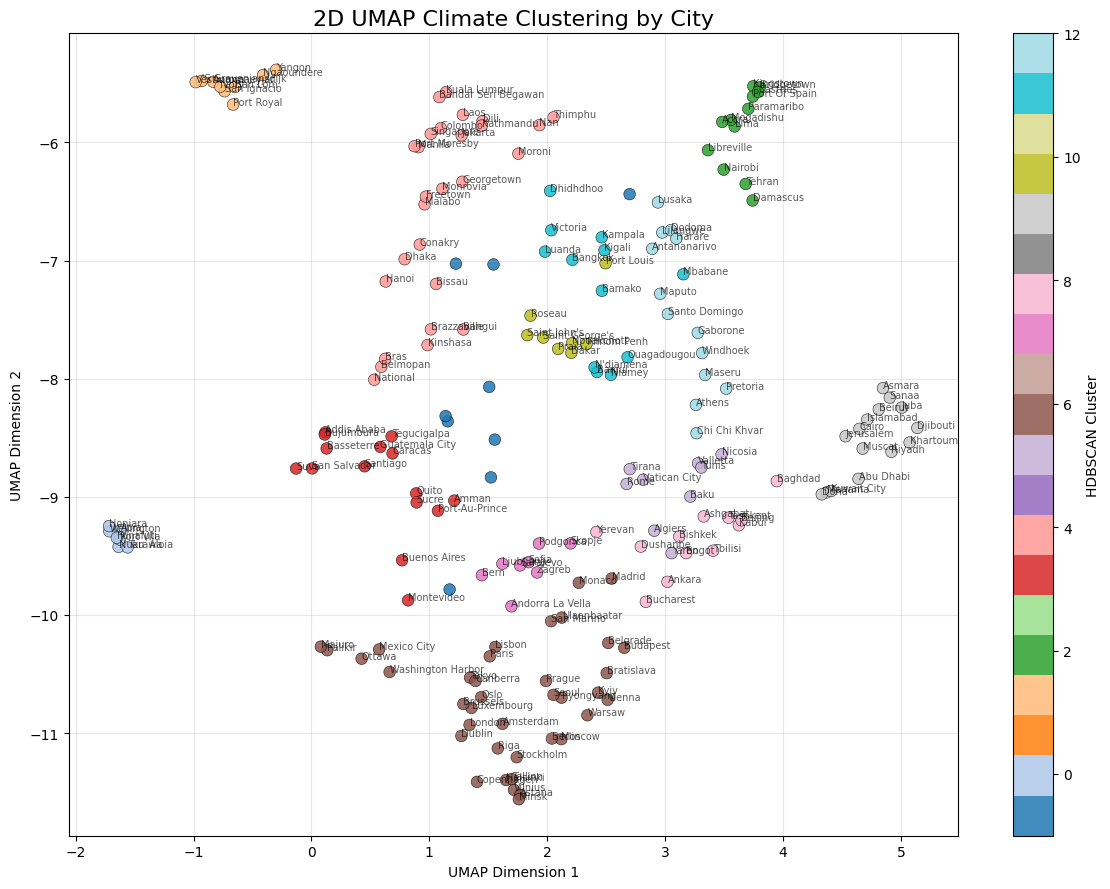

Saved 2D plot: /content/drive/MyDrive/Weather Trend Forecasting/eda_outputs/climate_region_clustering/figures/umap_2d_hdbscan_climate_clusters.png


In [ ]:
# 2D UMAP cluster plot

plt.figure(figsize=(12, 9))
scatter = plt.scatter(
    umap_df["UMAP2_1"],
    umap_df["UMAP2_2"],
    c=umap_df["cluster"],
    cmap="tab20",
    s=70,
    alpha=0.85,
    edgecolors="black",
    linewidths=0.4
)

plt.colorbar(scatter, label="HDBSCAN Cluster")
plt.title("2D UMAP Climate Clustering by City", fontsize=16)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.grid(alpha=0.3)

for _, row in umap_df.iterrows():
    if row["cluster"] == -1:
        continue

    plt.text(
        row["UMAP2_1"],
        row["UMAP2_2"],
        str(row["location_name"]),
        fontsize=7,
        alpha=0.65
    )

plt.tight_layout()
fig_path_2d = os.path.join(
    FIG_DIR,
    "umap_2d_hdbscan_climate_clusters.png"
)

plt.savefig(fig_path_2d, dpi=300, bbox_inches="tight")
plt.show()
print("Saved 2D plot:", fig_path_2d)

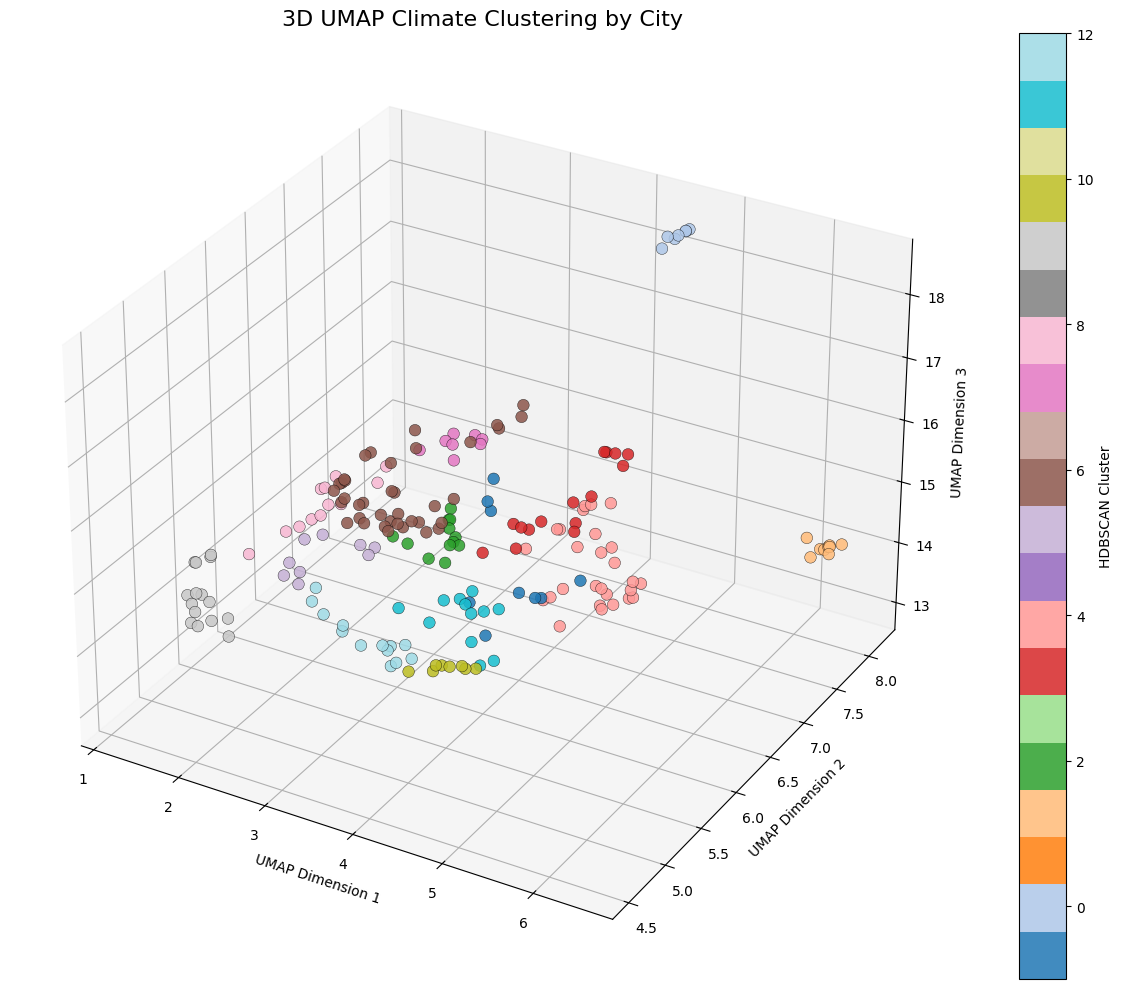

Saved 3D plot: /content/drive/MyDrive/Weather Trend Forecasting/eda_outputs/climate_region_clustering/figures/umap_3d_hdbscan_climate_clusters.png


In [ ]:
# 3D UMAP cluster plot

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(13, 10))
ax = fig.add_subplot(
    111,
    projection="3d"
)

scatter = ax.scatter(
    umap_df["UMAP3_1"],
    umap_df["UMAP3_2"],
    umap_df["UMAP3_3"],
    c=umap_df["cluster"],
    cmap="tab20",
    s=70,
    alpha=0.85,
    edgecolors="black",
    linewidths=0.3
)

ax.set_title("3D UMAP Climate Clustering by City", fontsize=16)
ax.set_xlabel("UMAP Dimension 1")
ax.set_ylabel("UMAP Dimension 2")
ax.set_zlabel("UMAP Dimension 3")
fig.colorbar(scatter, ax=ax, label="HDBSCAN Cluster")
plt.tight_layout()
fig_path_3d = os.path.join(
    FIG_DIR,
    "umap_3d_hdbscan_climate_clusters.png"
)

plt.savefig(fig_path_3d, dpi=300, bbox_inches="tight")
plt.show()
print("Saved 3D plot:", fig_path_3d)

In [ ]:
# Save final report info

report_info = {
    "selected_city_count_length_gt400": len(city_feature_df),
    "original_weather_feature_count": len(weather_features),
    "raw_engineered_feature_count": len(feature_cols),
    "filtered_scaled_feature_count": X_scaled.shape[1],
    "pca_dimension_90_variance": X_pca.shape[1],
    "pca_explained_variance_sum": pca_full.explained_variance_ratio_.sum(),
    "hdbscan_cluster_count_excluding_noise": len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0),
    "hdbscan_noise_count": int(np.sum(cluster_labels == -1))
}
report_info_df = pd.DataFrame([report_info])
display(report_info_df)
report_info_df.to_csv(
    os.path.join(REPORT_DIR, "climate_clustering_pipeline_summary.csv"),
    index=False
)
print("All results saved to:")
print(OUTPUT_DIR)

,selected_city_count_length_gt400,original_weather_feature_count,raw_engineered_feature_count,filtered_scaled_feature_count,pca_dimension_90_variance,pca_explained_variance_sum,hdbscan_cluster_count_excluding_noise,hdbscan_noise_count
0,194,11,204,202,26,0.981248,13,9


All results saved to:
/content/drive/MyDrive/Weather Trend Forecasting/eda_outputs/climate_region_clustering


In [ ]:
# Save cities in each climate cluster

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
except ImportError:
    !pip install cartopy -q
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

CLUSTER_DIR = os.path.join(DATA_DIR, "cluster_city_lists")
os.makedirs(CLUSTER_DIR, exist_ok=True)

# Make sure cluster information exists
if "cluster" not in umap_df.columns:
    umap_df["cluster"] = cluster_labels

# Build final cluster-city table
cluster_city_df = umap_df[
    [
        "country",
        "location_name",
        "latitude",
        "longitude",
        "sequence_length",
        "cluster",
        "cluster_probability"
    ]
].copy()

cluster_city_df = cluster_city_df.sort_values(
    ["cluster", "country", "location_name"]
)

# Save all cities with cluster labels
all_cluster_path = os.path.join(
    DATA_DIR,
    "all_cities_with_climate_clusters.csv"
)

cluster_city_df.to_csv(
    all_cluster_path,
    index=False
)

print("Saved all cluster-city table:")
print(all_cluster_path)
display(cluster_city_df.head())

Saved all cluster-city table:
/content/drive/MyDrive/Weather Trend Forecasting/eda_outputs/climate_region_clustering/data/all_cities_with_climate_clusters.csv


,country,location_name,latitude,longitude,sequence_length,cluster,cluster_probability
127,Bahamas,Nassau,25.082674,-77.350000,722,-1,0.0
129,Benin,Porto-Novo,6.482673,2.617327,726,-1,0.0
13,Cuba,Havana,23.131535,-82.363393,723,-1,0.0
65,India,New Delhi,28.600000,77.200000,725,-1,0.0
69,Liechtenstein,Vaduz,47.132673,9.517327,726,-1,0.0


In [ ]:
# Save one CSV for each cluster

cluster_summary_records = []
for cluster_id in sorted(cluster_city_df["cluster"].unique()):

    one_cluster_df = cluster_city_df[
        cluster_city_df["cluster"] == cluster_id
    ].copy()

    if cluster_id == -1:
        cluster_name = "noise"
    else:
        cluster_name = f"cluster_{cluster_id}"

    save_path = os.path.join(
        CLUSTER_DIR,
        f"{cluster_name}_cities.csv"
    )

    one_cluster_df.to_csv(
        save_path,
        index=False
    )

    cluster_summary_records.append({
        "cluster": cluster_id,
        "city_count": len(one_cluster_df),
        "mean_probability": one_cluster_df["cluster_probability"].mean(),
        "csv_path": save_path
    })

    print(f"\n===== Cluster {cluster_id} | {len(one_cluster_df)} cities =====")
    display(one_cluster_df[
        [
            "country",
            "location_name",
            "latitude",
            "longitude",
            "cluster_probability"
        ]
    ])

cluster_city_summary_df = pd.DataFrame(cluster_summary_records)
cluster_summary_path = os.path.join(
    DATA_DIR,
    "cluster_city_summary.csv"
)

cluster_city_summary_df.to_csv(
    cluster_summary_path,
    index=False
)

print("Saved cluster summary:")
print(cluster_summary_path)


===== Cluster -1 | 9 cities =====


,country,location_name,latitude,longitude,cluster_probability
127,Bahamas,Nassau,25.082674,-77.350000,0.0
129,Benin,Porto-Novo,6.482673,2.617327,0.0
13,Cuba,Havana,23.131535,-82.363393,0.0
65,India,New Delhi,28.600000,77.200000,0.0
69,Liechtenstein,Vaduz,47.132673,9.517327,0.0
85,Morocco,Rabat,34.026188,-6.836837,0.0
167,Nicaragua,Managua,12.150647,-86.268625,0.0
54,Nigeria,Abuja,9.176603,7.180647,0.0
9,Panama,Panama City,8.967334,-79.532666,0.0



===== Cluster 0 | 7 cities =====


,country,location_name,latitude,longitude,cluster_probability
120,Kiribati,Tarawa,-0.882677,169.532677,1.0
97,New Zealand,Wellington,-41.300000,174.782668,1.0
66,Samoa,Apia,-13.832668,-171.732668,1.0
151,Solomon Islands,Honiara,-9.432669,159.950000,1.0
95,Tonga,Nuku`Aloia,-21.132671,-175.200000,1.0
171,Tuvalu,Funafuti,-8.517331,179.217331,1.0
114,Vanuatu,Port Vila,-17.732674,168.317326,1.0



===== Cluster 1 | 9 cities =====


...


===== Cluster 11 | 12 cities =====


,country,location_name,latitude,longitude,cluster_probability
1,Angola,Luanda,-8.838625,13.233559,1.000000
174,Burkina Faso,Ouagadougou,12.370243,-1.523808,1.000000
84,Chad,N'djamena,12.112508,15.049353,1.000000
74,Gambia,Banjul,13.452513,-16.577973,1.000000
27,Maldives,Dhidhdhoo,6.882816,73.100000,0.995889
18,Mali,Bamako,12.650000,-8.000000,1.000000
26,Niger,Niamey,13.572416,1.994881,1.000000
165,Rwanda,Kigali,-1.952917,30.060486,1.000000
180,Seychelles Islands,Victoria,-4.617328,55.450000,0.995889
177,Swaziland,Mbabane,-26.317328,31.132672,1.000000



===== Cluster 12 | 13 cities =====


,country,location_name,latitude,longitude,cluster_probability
128,Botswana,Gaborone,-24.647088,25.911537,1.000000
64,Dominican Republic,Santo Domingo,18.467329,-69.900000,1.000000
33,Greece,Athens,37.979595,23.716920,1.000000
139,Iran,Chi Chi Khvar,36.261999,46.590000,1.000000
22,Lesotho,Maseru,-29.317328,27.482672,1.000000
150,Madagascar,Antananarivo,-18.917331,47.517331,0.956392
46,Malawi,Lilongwe,-13.982669,33.782669,0.956392
115,Mozambique,Maputo,-25.966199,32.589353,1.000000
123,Namibia,Windhoek,-22.571377,17.081782,1.000000
170,South Africa,Pretoria,-25.747493,28.188382,1.000000


Saved cluster summary:
/content/drive/MyDrive/Weather Trend Forecasting/eda_outputs/climate_region_clustering/data/cluster_city_summary.csv


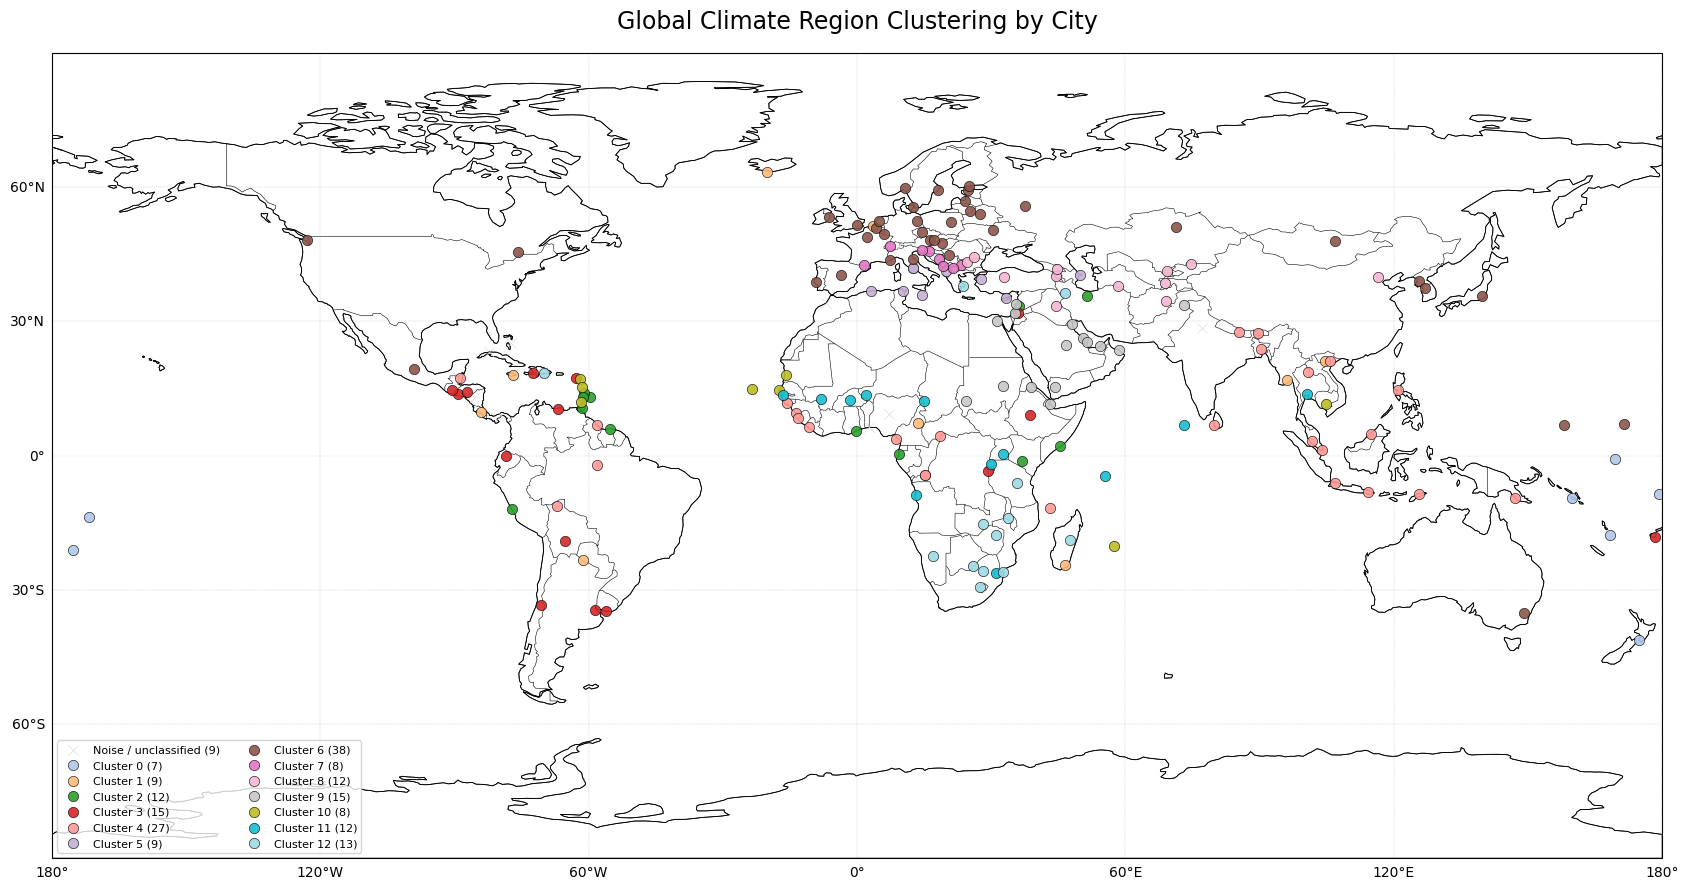

Saved cluster world map:
/content/drive/MyDrive/Weather Trend Forecasting/eda_outputs/climate_region_clustering/figures/global_climate_region_clusters_world_map.png


In [ ]:
# Plot climate clusters on world map

def plot_cluster_world_map(
    cluster_df,
    title,
    output_filename,
    include_noise=True
):
    plot_df = cluster_df.copy()
    if not include_noise:
        plot_df = plot_df[
            plot_df["cluster"] != -1
        ].copy()
    fig = plt.figure(figsize=(18, 9))
    ax = plt.axes(
        projection=ccrs.PlateCarree()
    )
    ax.set_global()

    # Black-white world map background
    ax.add_feature(
        cfeature.OCEAN,
        facecolor="white",
        zorder=0
    )

    ax.add_feature(
        cfeature.LAND,
        facecolor="white",
        edgecolor="black",
        linewidth=0.45,
        zorder=0
    )

    ax.add_feature(
        cfeature.COASTLINE,
        edgecolor="black",
        linewidth=0.65,
        zorder=2
    )

    ax.add_feature(
        cfeature.BORDERS,
        edgecolor="black",
        linewidth=0.4,
        zorder=2
    )

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.3,
        color="gray",
        alpha=0.45,
        linestyle="--"
    )

    gl.top_labels = False
    gl.right_labels = False
    clusters = sorted(plot_df["cluster"].unique())
    cmap = plt.get_cmap("tab20", len(clusters))
    cluster_to_color_index = {
        cluster_id: i
        for i, cluster_id in enumerate(clusters)
    }

    # Plot each cluster separately so legend is readable
    for cluster_id in clusters:

        sub = plot_df[
            plot_df["cluster"] == cluster_id
        ]

        if cluster_id == -1:
            label = f"Noise / unclassified ({len(sub)})"
            color = "lightgray"
            marker = "x"
            size = 55
            alpha = 0.85
        else:
            label = f"Cluster {cluster_id} ({len(sub)})"
            color = cmap(cluster_to_color_index[cluster_id])
            marker = "o"
            size = 55
            alpha = 0.9

        ax.scatter(
            sub["longitude"],
            sub["latitude"],
            s=size,
            c=[color],
            marker=marker,
            edgecolors="black" if cluster_id != -1 else "gray",
            linewidths=0.45,
            alpha=alpha,
            transform=ccrs.PlateCarree(),
            zorder=4,
            label=label
        )

    ax.set_title(
        title,
        fontsize=17,
        pad=18
    )

    ax.legend(
        loc="lower left",
        fontsize=8,
        frameon=True,
        ncol=2
    )

    plt.tight_layout()

    save_path = os.path.join(
        FIG_DIR,
        output_filename
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved cluster world map:")
    print(save_path)


plot_cluster_world_map(
    cluster_df=cluster_city_df,
    title="Global Climate Region Clustering by City",
    output_filename="global_climate_region_clusters_world_map.png",
    include_noise=True
)

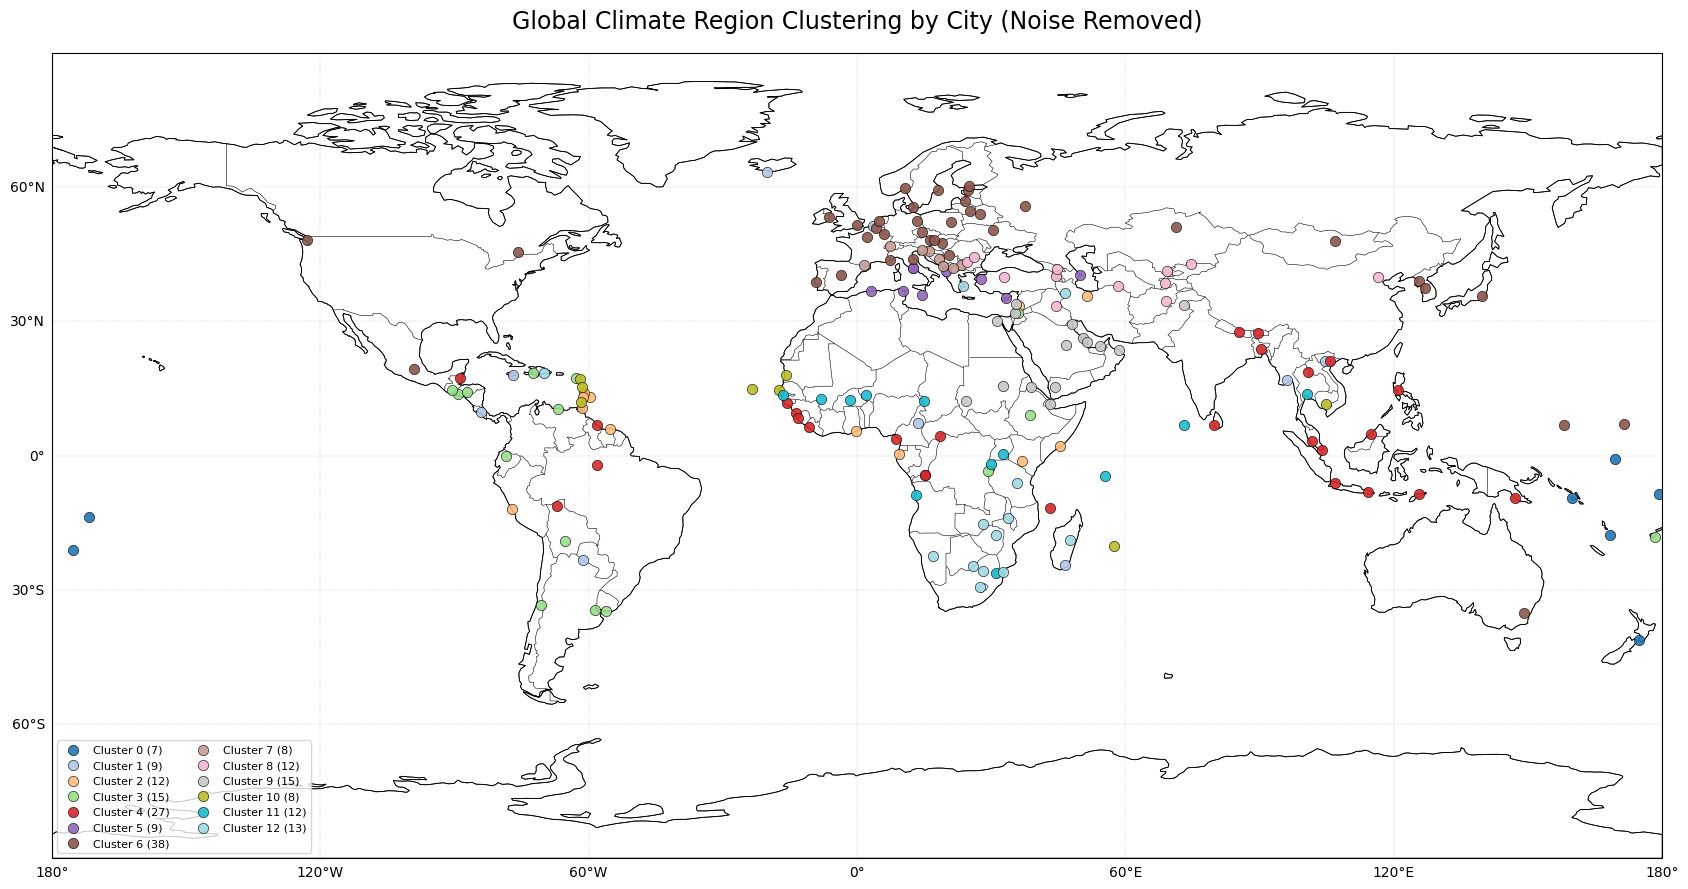

Saved cluster world map:
/content/drive/MyDrive/Weather Trend Forecasting/eda_outputs/climate_region_clustering/figures/global_climate_region_clusters_world_map_no_noise.png


In [ ]:
plot_cluster_world_map(
    cluster_df=cluster_city_df,
    title="Global Climate Region Clustering by City (Noise Removed)",
    output_filename="global_climate_region_clusters_world_map_no_noise.png",
    include_noise=False
)